#### Was ist Pandas ?

* wikipedia: pandas ist eine Programmbibliothek für Python zur Verarbeitung, Analyse und Darstellung von Daten.  
Insbesondere enthält sie Datenstrukturen und Operatoren für den Zugriff auf numerische Tabellen und Zeitreihen. 

* "At the very basic level, Pandas objects can be thought of as enhanced versions of NumPy structured arrays in which the rows and columns are identified with labels rather than simple integer indices" - 



#### Installation

https://pandas.pydata.org/pandas-docs/version/0.17.0/install.html

* mittels __Anaconda__:  
    über UI nach pandas suchen und in der gewünschten Environment installieren
* mittels __Pip__:  
    `pip install pandas`
* mittels __conda__:  
    `conda install pandas`




#### Installation testen

In [3]:
#import pandas
#pandas.__version__

import pandas as pd # "pd" <= Convention
print("Pandas-Version:",pd.__version__)



Pandas-Version: 2.0.2


#### Build-In-Documentation

In [2]:
# pd.<TAB>

# pd?

#help(pd)

#### Fundamentale Datenstrukturen von Pandas:

* `Series`
* `DataFrame`
* (`index`)

<img src="img/series-and-dataframe.png" width="200"/>






#### Series Objekt  
  
Konstruktion


In [5]:
import pandas as pd 

# aus einer Liste
data = pd.Series([1,2,3,4,5,6]) 
data = pd.Series([0.25, 0.5, 0.75, 1]) # upcasting
#data = pd.Series([1,"test",3,4,5,6]) # Heterogene Listen sind möglich

# aus einem Numpy-Array
#import numpy as np
#np_array = np.array([0.1, 5., 3.3])
#data = pd.Series(np_array)

print(data)

0       1
1    test
2       3
3       4
4       5
5       6
dtype: object


dtype ist ein numpy-datatype

vgl. https://numpy.org/doc/stable/user/basics.types.html

- Data type 	Description
- **bool_ 	Boolean (True or False) stored as a byte**
- int_ 	Default integer type (same as C long; normally either int64 or int32)
- intc 	Identical to C int (normally int32 or int64)
- intp 	Integer used for indexing (same as C ssize_t; normally either int32 or int64)
- int8 	Byte (-128 to 127)
- int16 	Integer (-32768 to 32767)
- int32 	Integer (-2147483648 to 2147483647)
- **int64 	Integer (-9223372036854775808 to 9223372036854775807)**
- uint8 	Unsigned integer (0 to 255)
- uint16 	Unsigned integer (0 to 65535)
- uint32 	Unsigned integer (0 to 4294967295)
- uint64 	Unsigned integer (0 to 18446744073709551615)
- float_ 	Shorthand for float64.
- float16 	Half precision float: sign bit, 5 bits exponent, 10 bits mantissa
- float32 	Single precision float: sign bit, 8 bits exponent, 23 bits mantissa
- **float64 	Double precision float: sign bit, 11 bits exponent, 52 bits mantissa**
- complex_ 	Shorthand for complex128.
- complex64 	Complex number, represented by two 32-bit floats
- complex128 	Complex number, represented by two 64-bit floats

#### dtype kann im Konstruktor mit angegeben werden

In [16]:
import numpy as np

np_array = np.array([0.0,1.1,2.2,3.3,4.4,5.5,6.6])
data = pd.Series(np_array,dtype='float32',name= 'Numbers')

print(data)

0    0.0
1    1.1
2    2.2
3    3.3
4    4.4
5    5.5
6    6.6
Name: Numbers, dtype: float32


#### Series Values and indices 

In [17]:
print(data.values)
print(type(data.values))  # Numpy-Array


[0.  1.1 2.2 3.3 4.4 5.5 6.6]
<class 'numpy.ndarray'>


In [10]:
print(data.index)
print(type(data.index)) # RangeIndex => 
print(type(range(0,7,1))) #

RangeIndex(start=0, stop=7, step=1)
<class 'pandas.core.indexes.range.RangeIndex'>
<class 'range'>


#### Slicing ist auch mit Series-Objekten möglich

In [24]:
print(data)
print("data[1]: ",data[1], type(data[1]))
print("data[1:3]:")
print(data[1:3])
print("data[1:]: ")
print(data[1:])
#print("data[::2]: ",data[::2])

0    0.0
1    1.1
2    2.2
3    3.3
4    4.4
5    5.5
6    6.6
Name: Numbers, dtype: float32
data[1]:  1.1 <class 'numpy.float32'>
data[1:3]:
1    1.1
2    2.2
Name: Numbers, dtype: float32
data[1:]: 
1    1.1
2    2.2
3    3.3
4    4.4
5    5.5
6    6.6
Name: Numbers, dtype: float32


#### Series - ein generalisiertes Numpy-Array
- Ein **Series Objekt** ist nach dem bisherigen Wissensstand mehr oder weniger wie ein **1-dimensionales-Numpy-Array**. 
- das **Numpy-Array** verwendet einen impliziten **Integer-Index** (von 0 bis n)
- Das **Series Objekt** hingegen kann einen explizit defininerten Index, der mit den Werten assoziiert ist, haben
- Als Index müssen daher KEINE Integerwerte verwendet werden (a)
- die Indices müssen NICHT aufeinander folgend sein (b)




In [25]:
# Labels als index

data = pd.Series([0.25, 0.5, 0.75, 1.0],
                 index=['a', 'b', 'c', 'd'])
print(data)           

#print(pd.Series(5, index=[100, 200, 300]))


data = pd.Series([0.25, 0.5, 0.75, 1.0],
                 index=[3,7,14,7])
print(data)     


population_dict = {'California': 38332521,
                   'Texas': 26448193,
                   'New York': 19651127,
                   'Florida': 19552860,
                   'Illinois': 12882135}
                   
population = pd.Series(population_dict)
population



a    0.25
b    0.50
c    0.75
d    1.00
dtype: float64
3     0.25
7     0.50
14    0.75
7     1.00
dtype: float64


California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

Series könnten wie Dictionaries manipuliert werden:

In [ ]:
# ein Element abfragen
print("population['California'] ",population['California'])

# ein Element hinzufügen
population['Oregon'] = 12001100
print(population)

# slicing
print(population['Texas':"Illinois"])




population['California']  38332521
California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
Oregon        12001100
dtype: int64
Texas       26448193
New York    19651127
Florida     19552860
Illinois    12882135
dtype: int64


Eine Series kann auch aus einem Dictionary erzeugt werden, die Indices entsprechen dann den Keys des Dictionary
Dann kann der dtype vom Typ Object sein:

In [26]:
pd.Series({2:'a', 1:'b', 3:'ca'})  #obwohl eigentlich string
#print(pd.Index)

2     a
1     b
3    ca
dtype: object

Wird eine Series mit Index angegeben werden nur die Werte verwendet die im Index vorhanden sind und in der gleichen Reihenfolge wie der Index

In [ ]:
pd.Series({2:'a', 1:'b', 3:'c'}, index=[3, 2])

3    c
2    a
dtype: object

Eine Pandas-Series kann wieder in eine Python-Liste konvertiert werden

In [8]:
import pandas as pd

pd_series = pd.Series(['a','b','c'])
mylist = pd_series.tolist()
print(mylist)
print(type(mylist))


['a', 'b', 'c']
<class 'list'>


### Das DataFrame-Objekt

- das DataFrame-Objekt kann man sich wie ein 2-dimensionales Python oder Numpy-Array vorstellen
- oder etwas präziser als mehrere Series Objekte nebeneinander die sich einen Index teilen 
- im prinzip eine Tabelle mit Zeilen und Spalten bezeichern
- wie bei der Series können Indizes und Spalten flexibel gewählt werden
- die Daten lassen sich auf vielfältige Weise  manipulieren und ergänzen

### Konstuktions-Möglichkeiten

In [ ]:
# als verknüpfung von Series-Objekten:
population_dict = {'California': 38332521,
                   'Texas': 26448193,
                   'New York': 19651127,
                   'Florida': 19552860,
                   'Illinois': 12882135}
population = pd.Series(population_dict)


area_dict = {'California': 423967, 'Texas': 695662, 'New York': 141297,
             'Florida': 170312, 'Illinois': 149995}
area = pd.Series(area_dict)
area

states = pd.DataFrame({'population': population,
                       'area': area})
states
#type(states)

,population,area
California,38332521,423967.0
Florida,19552860,170312.0
Illinois,12882135,149995.0
New York,19651127,141297.0
Oregon,12001100,NaN
Texas,26448193,695662.0


Wenn Daten nicht vorhanden sind wie im letzten Beispiel, werden die Felder mit NaN gefüllt (Not a number)

# Ein Dataframe kann aus einer csv-Datei erzeugt werden:

In [29]:
import pandas as pd
df = pd.read_csv('data/people.csv',sep=',', index_col='Index')
print(df) 


               User Id First Name  Last Name     Sex  \
Index                                                  
1      88F7B33d2bcf9f5     Shelby    Terrell    Male   
2      f90cD3E76f1A9b9    Phillip    Summers  Female   
3      DbeAb8CcdfeFC2c   Kristine     Travis    Male   
4      A31Bee3c201ef58    Yesenia   Martinez    Male   
5      1bA7A3dc874da3c       Lori       Todd    Male   
...                ...        ...        ...     ...   
96     5eFda7caAeB260E     Dennis     Barnes  Female   
97     CCbFce93d3720bE      Steve  Patterson  Female   
98     2fEc528aFAF0b69     Wesley       Bray    Male   
99     Adc7ad9B6e4A1Fe     Summer   Oconnell  Female   
100    b8D0aD3490FC7e1     Mariah    Bernard    Male   

                            Email                   Phone Date of birth  \
Index                                                                     
1            elijah57@example.net  001-084-906-7849x73518    1945-10-26   
2           bethany14@example.com       214.11

#### Die Funktion groupby ermöglicht die Gruppierung von Daten basieren auf Werten einer Spalte so daß auf diese Gruppen funktionen angewendet werden können wie:  
* mean() (arithmetisches Mittel)
* max()
* min()
* sum()


In [1]:
import pandas as pd
df = pd.read_csv('data/weather.csv')

print(df)
df.groupby('city')['temperature'].mean()
df.groupby('city')['temperature'].max()
df.groupby('city')['temperature'].min()
df.groupby('city')['temperature'].sum()

       date      city  temperature  humidity
0  5/1/2017  new york           65        56
1  5/2/2017  new york           66        58
2  5/3/2017  new york           68        60
3  5/1/2017    mumbai           75        80
4  5/2/2017    mumbai           78        83
5  5/3/2017    mumbai           82        85
6  5/1/2017   beijing           80        26
7  5/2/2017   beijing           77        30
8  5/3/2017   beijing           79        35


city
beijing     236
mumbai      235
new york    199
Name: temperature, dtype: int64

#### Evt. wollen wir nicht nur den Maximalen Wert eines Datensatzes wissen sondern den gesamten Datensatz erfragen

In [8]:
myid = df['temperature'].idxmax() # mit idxmax() lässt sich die id des Datensatzes mit der maximal-Temperatur abfragen
print(myid)
print(df.loc[myid]) # diese id kann verwendet werden um den ganzen Datensatz auszugeben

# Analog idxmin()
myid = df['humidity'].idxmin() # Datensatz mit der geringsten Humidity
print(myid)
print(df.loc[myid])


5
date           5/3/2017
city             mumbai
temperature          82
humidity             85
Name: 5, dtype: object
6
date           5/1/2017
city            beijing
temperature          80
humidity             26
Name: 6, dtype: object


In [30]:
# aus einem klassischen Python array
data = pd.DataFrame([[1,2],[3,4]])
data

# mit index und colums-labels im Konstruktor
data = pd.DataFrame([[1,2],[3,4]],index=range(3,5),columns=['foo', 'bar'])
data


,foo,bar
3,1,2
4,3,4


#### Das Index-Objekt
- das Index-Objekt ist Bestandteil des Series und DataFrame-Objekts
- man kann es sich als unveränderlichen Array (immutable) oder geordnete Menge (ordered set) vorstelle
- aber die Index-Werte können sich wiederholen


In [33]:
ind = pd.Index([2, 3, 5, 7, 11])
ind

Index([2, 3, 5, 7, 11], dtype='int64')

- standart Python Indexing/Slicing ist auch hier möglich

In [34]:
ind[1] = 0 # Fehler ! -  Index ist immutable

TypeError: Index does not support mutable operations

In [36]:

# Daten abfragen ist möglich 
ind[2] 

# jedes 2. ELement
ind[::2]

ind = pd.Index(['a','b']) # der index muss nicht numerisch sein
print(ind)


Index(['a', 'b'], dtype='object')


Weitere Eigenschaften analog zu Numpy-Arrays:

In [ ]:
print(ind.size, ind.shape, ind.ndim, ind.dtype) # attribute ähnlich zu Numpy-Arrays


2 (2,) 1 object


#### Index als gerordnete Menge: (*)


In [ ]:
indA = pd.Index([1, 3, 5, 7, 9])
indB = pd.Index([2, 3, 5, 7, 11])

In [ ]:
#indA & indB  # intersection

indA.intersection(indB)

Int64Index([3, 5, 7], dtype='int64')

In [ ]:
#indA | indB  # union

indA.union(indB)



Int64Index([1, 2, 3, 5, 7, 9, 11], dtype='int64')

In [ ]:
#ndA ^ indB  # symmetric difference

indA.symmetric_difference(indB)

Int64Index([1, 2, 9, 11], dtype='int64')

#### Daten Indexierung und Selection

1. Series

In [40]:

# Selection 
import pandas as pd
data = pd.Series([0.25, 0.5, 0.75, 1.0],
                 index=['a', 'b', 'c', 'd'])
data


a    0.25
b    0.50
c    0.75
d    1.00
dtype: float64

In [41]:
data['b']

0.5

#### Abfragen ob ein Key existiert

In [44]:
print('b' in data) # Key in data ?
print('z' in data) # Key in data ? 

True
False


#### Das Index-Objekt des Dataframes abfragen  
* Es kann mit der Funktion list() in ein Python-List umgewandelt werden

In [50]:
print(data.keys())
print(type(data.keys()))
print(list(data.keys()))

Index(['a', 'b', 'c', 'd'], dtype='object')
<class 'pandas.core.indexes.base.Index'>
['a', 'b', 'c', 'd']


In [51]:

print(data.items()) # .items() liefert Schlüssel/Wert-Paare welche in eine Liste umgewandelt werden können
print(type(data.items()))
list(data.items())


<class 'zip'>


[('a', 0.25), ('b', 0.5), ('c', 0.75), ('d', 1.0)]

Neue Series-Elemente können wie bei Python Dictionaries "einfach" hinzugefügt werden  

In [ ]:
data['e'] = 1.25 # Zeile hinzufügen
data

a    0.25
b    0.50
c    0.75
d    1.00
e    1.25
dtype: float64

In [ ]:
data['a':'c'] # slicing auf Zeilen

a    0.25
b    0.50
c    0.75
dtype: float64

In [ ]:
data[0:2]

a    0.25
b    0.50
dtype: float64

In [53]:
# masking
data[(data > 0.3) & (data < 0.8) | (data < 0.8) ]


a    0.25
b    0.50
c    0.75
dtype: float64

In [ ]:
# fancy indexing: die gewünschten Daten können mit einer Liste von Indices ausgewählt werden
data[['a', 'e','c']]

a    0.25
e    1.25
c    0.75
dtype: float64

#### Indexers

__Indexing und Slicing kann verwirrend sein (!):__
 

In [5]:
data = pd.Series(['a', 'b', 'c'], index=[1, 3, 5])
data

1    a
3    b
5    c
dtype: object

In [56]:
# explicit index , - den wir angegeben haben 
data[1]

'a'

In [57]:
# implicit index (python-array-like indexing)
data[1:3] # hier wird der implizite Index verwendet der von 0 bis 2 geht (wegen slicing ist die 3 exclusive )

3    b
5    c
dtype: object

um diese "Verwirrung" zu vermeiden bietet pandas spezielle indexing attribute:

- loc, iloc

a) loc =>  indexing und slicing mit expliciten index

In [ ]:
data.loc[1]

'a'

In [ ]:
data.loc[1:3] #  (expliziter Index (1,3,5) und "3" inclusive)

1    a
3    b
dtype: object

b) iloc: indexing und slicing mit dem impliziten Python-Style index

In [7]:
print(data)
data.iloc[0]
#data.iloc[1]
#data.iloc[2]


1    a
3    b
5    c
dtype: object


'a'

In [6]:
data.iloc[1:3] # (impliziter Index (0,1,2), 3 exclusive)

3    b
5    c
dtype: object

#### Selection im DataFrame

- DataFrame kann man sich als Dictionary von Series Objekten vorstellen und auch konstruiert werden

In [ ]:
area = pd.Series({'California': 423967, 'Texas': 695662,
                  'New York': 141297, 'Florida': 170312,
                  'Illinois': 149995})
pop = pd.Series({'California': 38332521, 'Texas': 26448193,
                 'New York': 19651127, 'Florida': 19552860,
                 'Illinois': 12882135})
data = pd.DataFrame({'area':area, 'pop':pop}) # !!
data

,area,pop
California,423967,38332521
Texas,695662,26448193
New York,141297,19651127
Florida,170312,19552860
Illinois,149995,12882135


In [ ]:
data['area'] 

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: area, dtype: int64

In [ ]:
data.area #  attribute-style access

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: area, dtype: int64

In [ ]:
data.area is data['area']

True

In [ ]:
data.pop is data['pop'] ## !!! funktiniert nicht immer

# => data['pop'] = z besser als data.pop = z


False

Spalten lassen sich leicht hinzufügen:

In [ ]:
data['density'] = data['pop'] / data['area']
data

,area,pop,density
California,423967,38332521,90.413926
Texas,695662,26448193,38.018740
New York,141297,19651127,139.076746
Florida,170312,19552860,114.806121
Illinois,149995,12882135,85.883763


#### DataFrame als zweidimensionales Array

=> Rohdaten:

In [ ]:
data.values

array([[4.23967000e+05, 3.83325210e+07, 9.04139261e+01],
       [6.95662000e+05, 2.64481930e+07, 3.80187404e+01],
       [1.41297000e+05, 1.96511270e+07, 1.39076746e+02],
       [1.70312000e+05, 1.95528600e+07, 1.14806121e+02],
       [1.49995000e+05, 1.28821350e+07, 8.58837628e+01]])

#### Transponieren (transpose) des DataFrame
d.h. Spalten und Zeilen werden vertauscht

In [ ]:
data.T

,California,Texas,New York,Florida,Illinois
area,4.239670e+05,6.956620e+05,1.412970e+05,1.703120e+05,1.499950e+05
pop,3.833252e+07,2.644819e+07,1.965113e+07,1.955286e+07,1.288214e+07
density,9.041393e+01,3.801874e+01,1.390767e+02,1.148061e+02,8.588376e+01


In [ ]:
data.values[0] # NUR die Werte der Zeile 0

array([4.23967000e+05, 3.83325210e+07, 9.04139261e+01])

In [ ]:
data['area'] # Zeile 'area' mit Labels

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: area, dtype: int64

In [ ]:
#data['California'] ## !!!

KeyError: 'California'

In [ ]:
#vgl. keys und index

#data.T
#data.keys
#data.index

# zurück transponieren
data.T
data

,area,pop,density
California,423967,38332521,90.413926
Texas,695662,26448193,38.018740
New York,141297,19651127,139.076746
Florida,170312,19552860,114.806121
Illinois,149995,12882135,85.883763


=> Spalten-Keys und Index bleiben bei Transponierung gleich

#### loc, ilocIndexer bei DataFrame

In [ ]:
data.iloc[:3, :1] # implizit (ex)
data.loc[:'Illinois', :'area'] # slicing
# data.ix[:3, :'pop'] #- deprecated ?

data.loc[data.density > 100, ['pop', 'density']]
data.iloc[0, :2] = 1 # 
data

,area,pop,density
California,1,1,1.000000
Texas,695662,26448193,38.018740
New York,141297,19651127,139.076746
Florida,170312,19552860,114.806121
Illinois,149995,12882135,85.883763


### Daten-Operationen

Beispiele:

In [ ]:
# eine Serie "ser" zum testen (zufällige-Werte)
import pandas as pd
import numpy as np

rng = np.random.RandomState(42) # random seed 42 vgl. Python Random-Modul (ohne Argument bei jedem aufruf eine random-funktionwire  eine neue Zufalls-Kombination ermittelt)
print("type(rng.randint(0, 10, 4)): ",type(rng.randint(0, 10, 4))) # => numpy.ndarray
ser = pd.Series(rng.randint(0, 10, 4)) # Werte von 0 -10 
ser


type(rng.randint(0, 10, 4)):  <class 'numpy.ndarray'>


0    6
1    9
2    2
3    6
dtype: int64

In [ ]:
# Ein DataFrame "df" zum testen (zufällige-Werte)
df = pd.DataFrame(rng.randint(0, 30, (3, 5)),
                  columns=['A', 'B', 'C', 'D','F']) # Werte von 0-30 in einer 3x5-Matrix  (3 Zeilen, 5 Spalten)


                
df                  

,A,B,C,D,F
0,25,10,10,4,22
1,28,14,25,3,19
2,11,18,12,7,22


In [ ]:
np.exp(ser) # exp(x) <=> e hoch x

#np.sin(df * np.pi / 4)

# und viele andere: 
# https://numpy.org/doc/stable/reference/arrays.ndarray.html





,A,B,C,D,F
0,7.071068e-01,1.0,1.000000e+00,1.224647e-16,-1.000000
1,8.572528e-16,-1.0,7.071068e-01,7.071068e-01,0.707107
2,7.071068e-01,1.0,3.673940e-16,-7.071068e-01,-1.000000


zwei weitere Series-Objekte

In [ ]:
area = pd.Series({'Alaska': 1723337, 'Texas': 695662,
                  'California': 423967}, name='area')
population = pd.Series({'California': 38332521, 'Texas': 26448193,
                        'New York': 19651127}, name='population')              

In [ ]:
population

california    38332521
Texas         26448193
New York      19651127
Name: population, dtype: int64

In [ ]:
area

Alaska        1723337
Texas          695662
California     423967
Name: area, dtype: int64

In [ ]:
population / area

Alaska              NaN
California    90.413926
New York            NaN
Texas         38.018740
dtype: float64

In [ ]:
area.index.union(population.index)

Index(['Alaska', 'California', 'New York', 'Texas'], dtype='object')

In [ ]:
A = pd.Series([2, 4, 6], index=[0, 1, 2])
B = pd.Series([1, 3, 5], index=[1, 2, 3])
A + B

#A = pd.Series([2, 4, 6])
#B = pd.Series([1, 3, 5])
#A + B



0    NaN
1    5.0
2    9.0
3    NaN
dtype: float64

In [ ]:
A.add(B, fill_value=0)

0    2.0
1    5.0
2    9.0
3    5.0
dtype: float64

#### Pandas-Matplot basics

<AxesSubplot:>

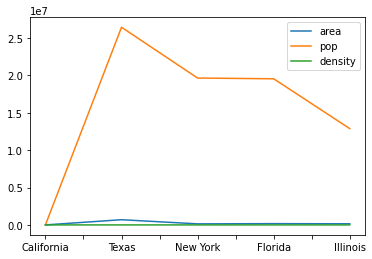

In [ ]:
data.plot()

<AxesSubplot:title={'center':'pandas example'}, xlabel='x-achse'>

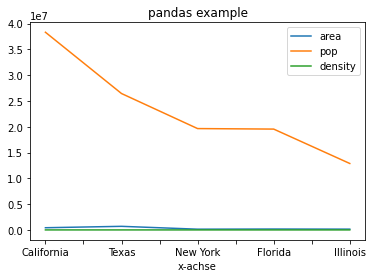

In [ ]:
data.plot(title="pandas example",xlabel="x-achse")

# weitere argumente
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html